In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import pyvista as pv
from mat4py import loadmat
import seaborn as sns
from scipy.stats import boxcox
from utils import boxcox_transform_forward

gt_color = np.array((59, 124, 243))/256
pr_color = np.array((117, 251, 76))/256

In [2]:
with open('data/burgers_step7.pkl', 'rb') as f:
    recipes, ingr_names, calorie_database = pickle.load(f)
n_recipes = len(recipes)
n_ingr = len(ingr_names)

### Some statistics

In [21]:
print("Number of recipes: ", n_recipes)
print("Number of ingredients: ", n_ingr)
print("recipes/ingredient: ", n_recipes/n_ingr)
temp = (recipes > 0) * (np.isnan(recipes))
temp = ((recipes > 0) | np.isnan(recipes)).astype(int)
temp = temp.sum(axis=1)
print(f"Number of ingredients per recipe [min, mean, max]: {temp.min()}, {temp.mean()}, {temp.max()}")

Number of recipes:  2216
Number of ingredients:  146
recipes/ingredient:  15.178082191780822
Number of ingredients per recipe [min, mean, max]: 2, 9.291967509025271, 23


### Most used ingredients by frequency

In [22]:
used_mask = recipes>0
freq = used_mask.sum(axis=0)
ranking = np.argsort(freq)

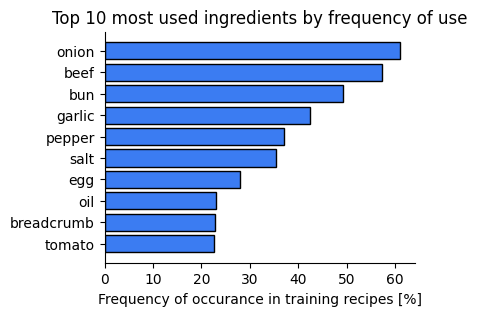

In [25]:
sorted_freq = freq[ranking]
sorted_names = ingr_names[ranking]

plt.figure(figsize=(4, 3))
plt.barh(sorted_names[-10:], sorted_freq[-10:]/len(recipes)*100, color=gt_color, edgecolor='k')
plt.xlabel('Frequency of occurance in training recipes [%]')
plt.title('Top 10 most used ingredients by frequency of use')

ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.savefig('figs/supplement_figs/freq.png', bbox_inches='tight')

### Most used ingredients by average mass (when used in a recipe)

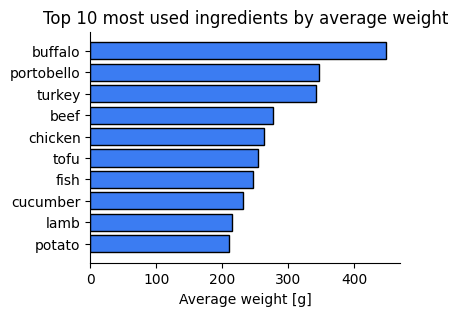

In [18]:
ave_masses = np.zeros(len(ingr_names))
for i in range(n_ingr):
    temp = recipes[:,i]
    temp = temp[temp>0]
    ave_masses[i] = np.mean(temp)

ranking = np.argsort(ave_masses)

sorted_masses = ave_masses[ranking]
sorted_names = ingr_names[ranking]

plt.figure(figsize=(4,3))
plt.barh(sorted_names[-10:], sorted_masses[-10:], color=gt_color, edgecolor='black')
plt.xlabel('Average weight [g]')
plt.title('Top 10 most used ingredients by average weight')

ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.savefig('figs/supplement_figs/mass1.png', bbox_inches='tight')

### Most used ingredients by average mass overall

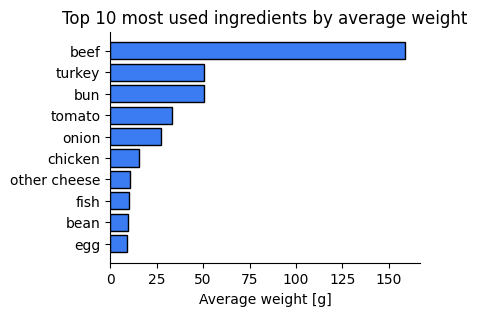

In [17]:
ave_masses = np.zeros(len(ingr_names))
for i in range(n_ingr):
    temp = recipes[:,i]
    temp = np.nan_to_num(temp)
    ave_masses[i] = np.mean(temp)

ranking = np.argsort(ave_masses)

sorted_masses = ave_masses[ranking]
sorted_names = ingr_names[ranking]

plt.figure(figsize=(4,3))
plt.barh(sorted_names[-10:], sorted_masses[-10:], color=gt_color, edgecolor='black')
plt.xlabel('Average weight [g]')
plt.title('Top 10 most used ingredients by average weight')

ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.savefig('figs/supplement_figs/mass2.png', bbox_inches='tight')

### The distributions of top 20 ingredients

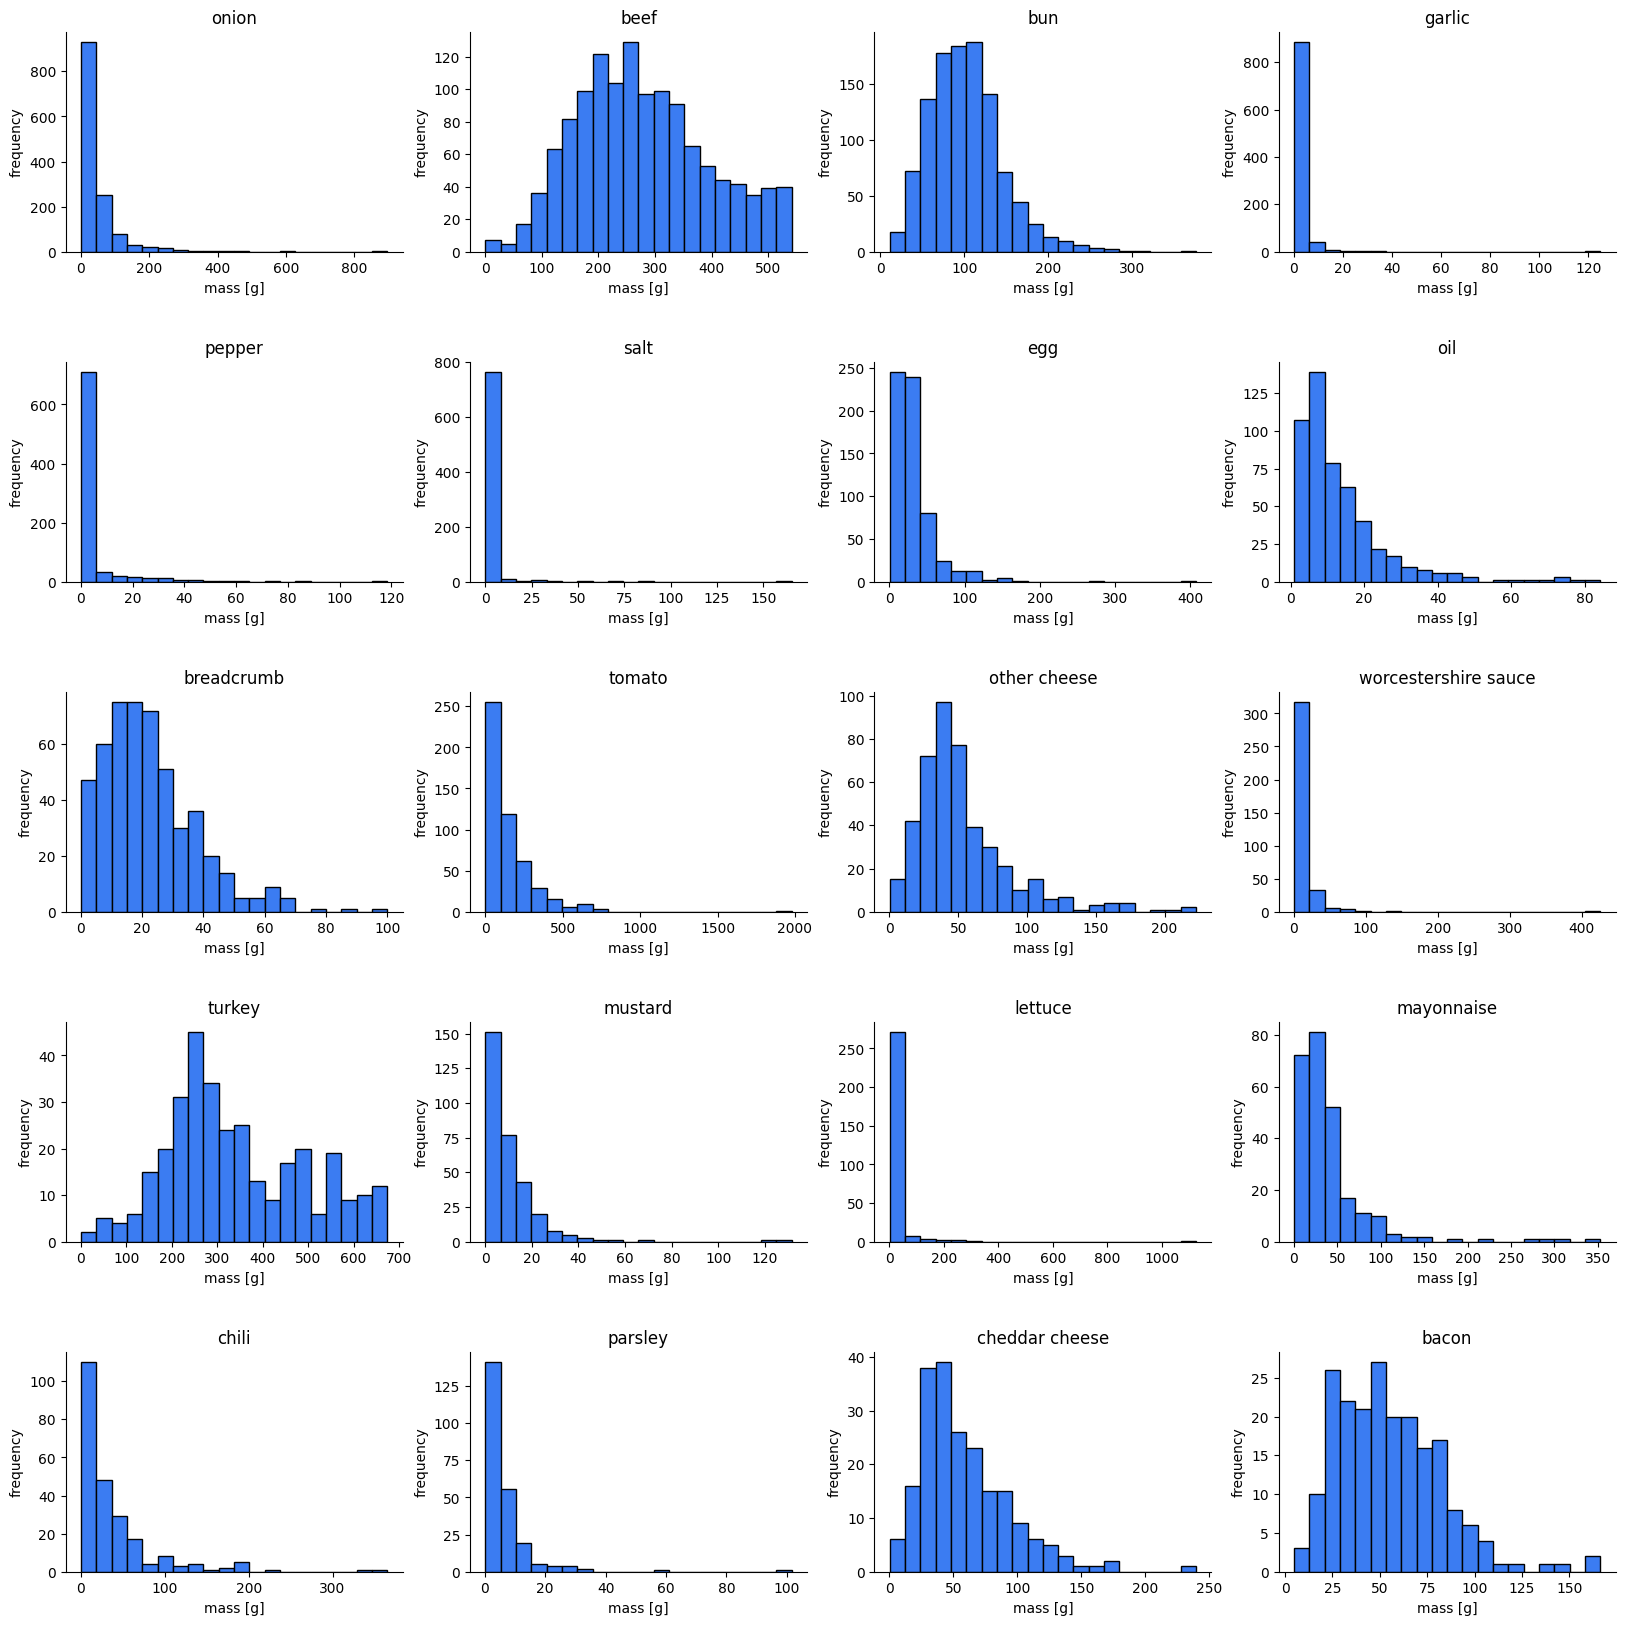

In [32]:
plt.figure(figsize=(20,20))

sorted_recipes = recipes[:,ranking]

for i in range(20):
    dist = sorted_recipes[:,-i-1]
    name = sorted_names[-i-1]
    plt.subplot(5,4,i+1)
    plt.hist(dist[dist>0], bins=20, color=gt_color, edgecolor='black')
    plt.title(name)
    plt.xlabel('weight [g]')
    plt.ylabel('frequency')

    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['top'].set_visible(False)
plt.subplots_adjust(hspace=0.5)



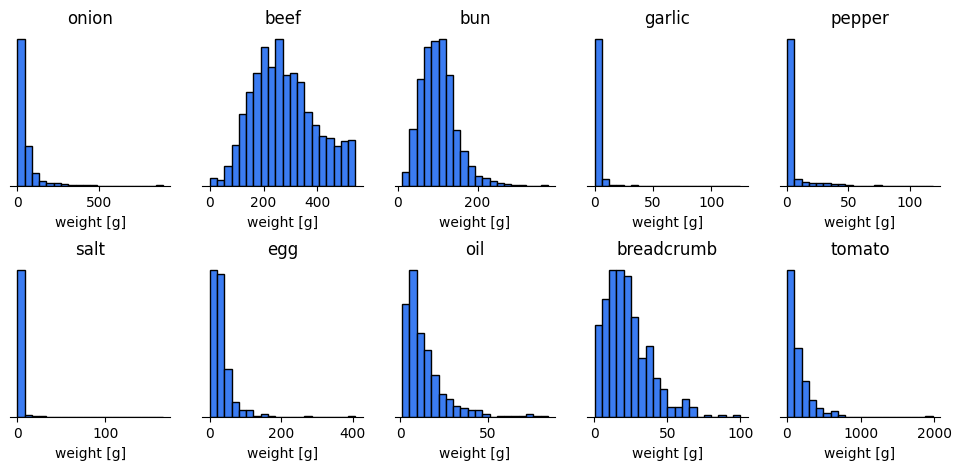

In [58]:
plt.figure(figsize=(12,5))

sorted_recipes = recipes[:,ranking]

for i in range(10):
    dist = sorted_recipes[:,-i-1]
    name = sorted_names[-i-1]
    plt.subplot(2,5,i+1)
    plt.hist(dist[dist>0], bins=20, color=gt_color, edgecolor='black')
    plt.title(name)
    plt.xlabel('weight [g]')
    plt.ylabel('frequency')

    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['left'].set_visible(False)
    plt.gca().get_yaxis().set_visible(False)

plt.subplots_adjust(hspace=0.5)

plt.savefig('figs/supplement_figs/dist_top20.png')

### Correlations of ingredients

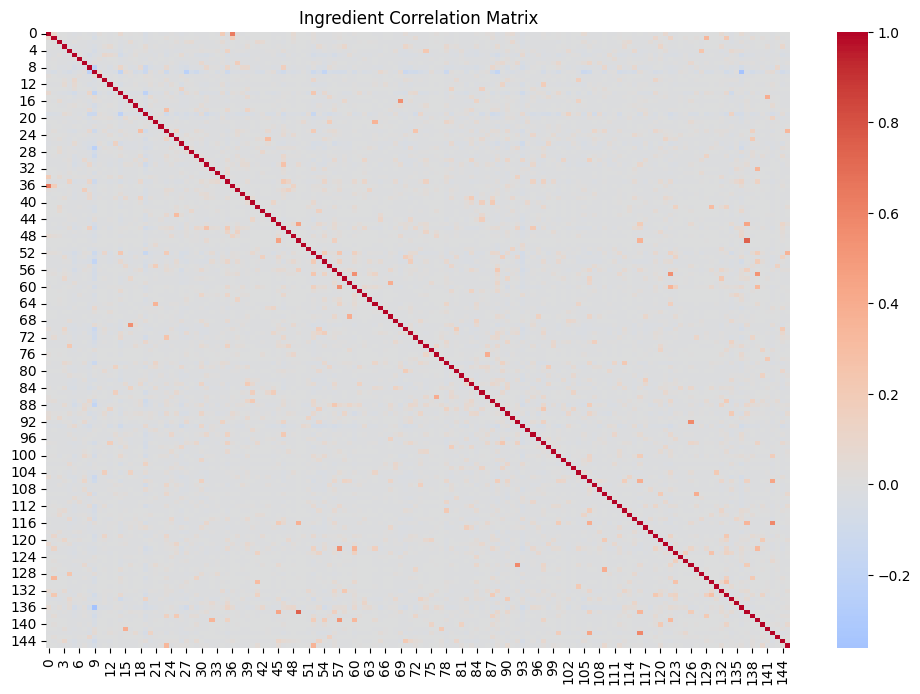

In [11]:
correlation_matrix = np.corrcoef(np.nan_to_num(recipes), rowvar=False)
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0)
plt.title("Ingredient Correlation Matrix")
plt.show()

In [12]:
pairs = []

n = correlation_matrix.shape[0]

for i in range(n):
    for j in range(i+1, n):  # j>i to avoid duplicates and diagonal
        ingredient1 = ingr_names[i]
        ingredient2 = ingr_names[j]
        corr_value = correlation_matrix[i, j]
        pairs.append((ingredient1, ingredient2, corr_value))
pairs_sorted = sorted(pairs, key=lambda x: x[2], reverse=True)

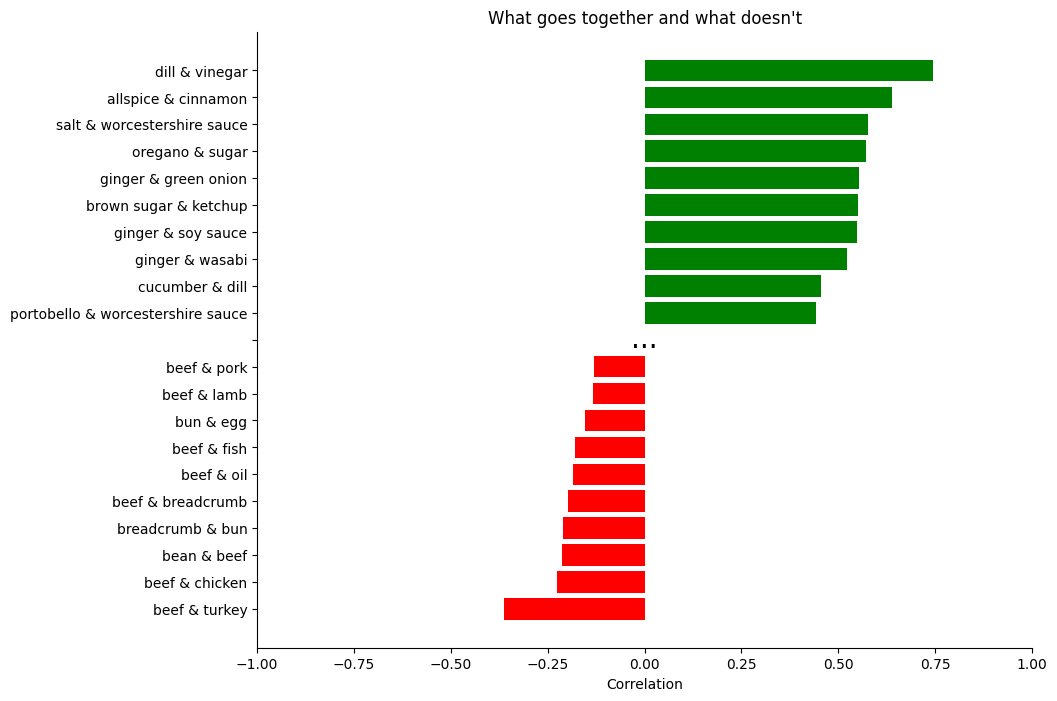

In [13]:
top_5 = pairs_sorted[:10]
bottom_5 = pairs_sorted[-10:]

top_labels = [f"{p[0]} & {p[1]}" for p in top_5]
top_values = [p[2] for p in top_5]

bottom_labels = [f"{p[0]} & {p[1]}" for p in bottom_5]
bottom_values = [p[2] for p in bottom_5]

combined_labels = top_labels + ['...'] + bottom_labels
combined_values = top_values + [None] + bottom_values  # None for ellipsis bar

fig, ax = plt.subplots(figsize=(10, 8))

# Bars for top 5
ax.barh(range(len(top_labels)), top_values, color='green')

# Bars for bottom 5, offset by len(top_labels) + 1 (for ellipsis)
ax.barh(range(len(top_labels) + 1, len(top_labels) + 1 + len(bottom_labels)), bottom_values, color='red')

# Set yticks with combined labels, placing empty label for ellipsis position
yticks_pos = list(range(len(combined_labels)))
yticks_labels = combined_labels.copy()

# Replace '...' with empty label, we'll add text manually
yticks_labels[ len(top_labels) ] = ''

ax.set_yticks(yticks_pos)
ax.set_yticklabels(yticks_labels)

# Add ellipsis text between groups
ax.text(0.0, len(top_labels), '...', fontsize=20, ha='center', va='center')

# Axis labels and title
ax.set_xlabel('Correlation')
ax.set_xlim(-1, 1)
ax.invert_yaxis()  # So highest correlation is at top

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.title('What goes together and what doesn\'t'); 


### Fill out nans with averages

A lot of ingredients have a `nan` quantity. I will fill these out with the average values of the recipes that utilize them.

In [14]:
n_nans = np.sum(np.isnan(recipes.flatten()))
print(f"Number of nan values: {n_nans} ({n_nans/len(recipes.flatten())}%)")

Number of nan values: 2345 (0.007248034221848573%)


In [15]:
averages = np.zeros(n_ingr)
for i in range(n_ingr):
    temp = []
    for j in range(n_recipes):
        if not np.isnan(recipes[j,i]) and recipes[j,i] > 0:
            temp.append(recipes[j,i])
    averages[i] = np.mean(temp)

for i in range(n_ingr):
    for j in range(n_recipes):
        if np.isnan(recipes[j,i]):
            recipes[j,i] = averages[i]

In [16]:
n_nans = np.sum(np.isnan(recipes.flatten()))
print(f"Number of nan values: {n_nans} ({n_nans/len(recipes.flatten())}%)")

Number of nan values: 0 (0.0%)


In [17]:
with open('data/burgers_step8.pkl', 'wb') as f:
    pickle.dump([recipes, ingr_names, calorie_database], f)

### Normalize the data

The distribution of every ingredient should be 

In [20]:
with open('data/burgers_step8.pkl', 'rb') as f:
    recipes, ingr_names, calorie_database = pickle.load(f)
n_recipes = len(recipes)
n_ingr = len(ingr_names)

# Normalize the data
data_normalized, fitted_lambdas, means_stds = boxcox_transform_forward(recipes)

gt_mask = np.array(data_normalized>0, dtype='int32')
gt_vals = np.array(data_normalized)

/Users/vtac/vtenv/lib/python3.12/site-packages/numpy/_core/_methods.py:197: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)


This needs fixing. The normalization should be done only on the values that are >0 (like above).

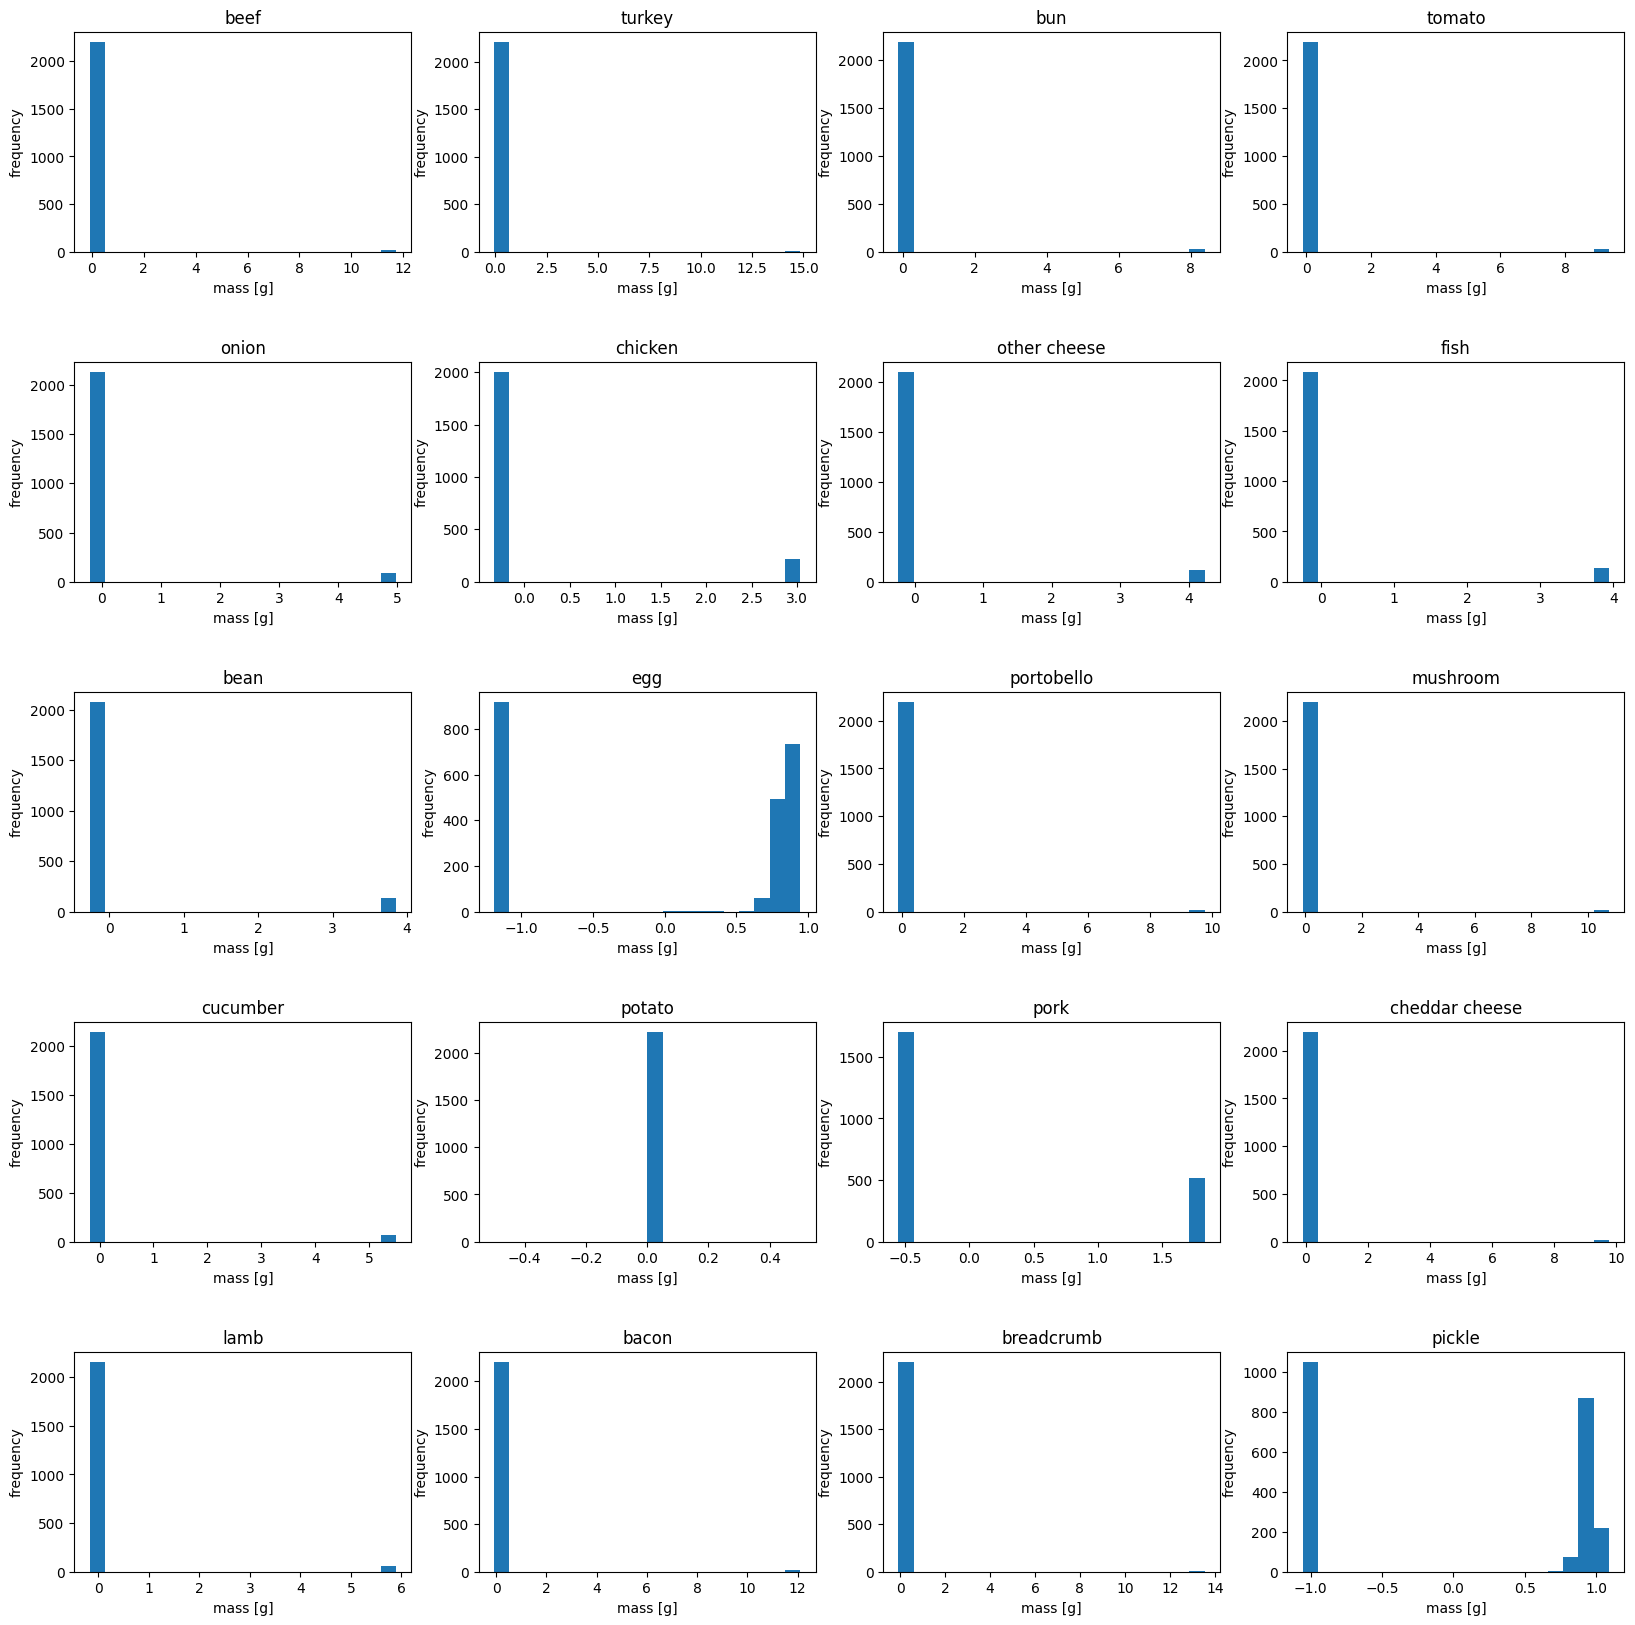

In [22]:
plt.figure(figsize=(20,20))

for i in range(20):
    dist = sorted_recipes[:,-i-1]
    name = sorted_names[-i-1]
    plt.subplot(5,4,i+1)
    plt.hist(data_normalized[:,i], bins=20)
    plt.title(name)
    plt.xlabel('mass [g]')
    plt.ylabel('frequency')
plt.subplots_adjust(hspace=0.5)